In [1]:
"""
mc_experiment.py -- shared core (Table "Software architecture", Section 3.4).

Factorial experiment: sensitivity of probabilistic investment appraisal to the
analyst's modelling choices.

Implements the protocol of Section 3, "Computational design":
  - Inverse-transform sampling with common random numbers
    (Beckman & McKay, 1987), to isolate the effect of each modelling choice
    from simulation noise.
  - Dependence induced via a Gaussian copula (Iman & Conover, 1982).
  - The identity P(NPV(i) < 0) = F_IRR(i), used to obtain the risk curve
    against the hurdle rate without solving for the IRR iteratively
    (Proposition 2, "Equivalence of the criteria under uncertainty").
  - Validation: simulated mean and variance checked against the closed forms
    of Proposition 1, "Moments of the NPV", and Table 1, "Moments implied by
    each family".

Fixed seeds -> reproducible. Every table in the Results section is generated
by the axis scripts built on this module.

Monetary values are in monetary units (m.u.); tables report '000 m.u.
"""
import numpy as np
from scipy import stats

MASTER_SEED = 2026
N_DEFAULT = 100_000

# ---------------------------------------------------------------------------
# 1. Canonical project (Table "Canonical project and three-point elicitation")
# ---------------------------------------------------------------------------
CANON = {
    "I": dict(a=480_000, m=500_000, b=540_000),
    "R": dict(a=270_000, m=300_000, b=336_000),
    "C": dict(a=138_000, m=150_000, b=165_000),
}
N_YEARS = 5
BASE_HURDLE = 0.12


def annuity_factor(hurdle, n=N_YEARS):
    """S = (1 - (1 + h)^-n) / h."""
    hurdle = np.asarray(hurdle, dtype=float)
    # limit as h -> 0
    return np.where(np.abs(hurdle) < 1e-12, float(n),
                    (1 - (1 + hurdle) ** (-n)) / hurdle)


# ---------------------------------------------------------------------------
# 2. Distribution families: map uniforms (0,1) -> values, given (a,m,b).
#    All receive the SAME vector of uniforms -> common random numbers.
# ---------------------------------------------------------------------------
def ppf_triangular(u, a, m, b):
    c = (m - a) / (b - a)
    return stats.triang.ppf(u, c=c, loc=a, scale=b - a)


def ppf_pert(u, a, m, b, lam=4.0):
    alpha1 = 1 + lam * (m - a) / (b - a)
    alpha2 = 1 + lam * (b - m) / (b - a)
    return a + (b - a) * stats.beta.ppf(u, alpha1, alpha2)


def ppf_uniform(u, a, m, b):
    # the mode is discarded by construction (Table 1, "Moments implied by
    # each family")
    return stats.uniform.ppf(u, loc=a, scale=b - a)


def ppf_normal_eq(u, a, m, b, ref="triangular"):
    """Normal matched to the first two moments of the reference family
    (pairing B: same moments, different shape)."""
    mu, var = MOMENTS[ref](a, m, b)
    return stats.norm.ppf(u, loc=mu, scale=np.sqrt(var))


def moments_triangular(a, m, b):
    mu = (a + m + b) / 3
    var = (a**2 + m**2 + b**2 - a*m - a*b - m*b) / 18
    return mu, var


def moments_pert(a, m, b, lam=4.0):
    mu = (a + lam * m + b) / (lam + 2)
    var = (mu - a) * (b - mu) / (lam + 3)
    return mu, var


def moments_uniform(a, m, b):
    mu = (a + b) / 2
    var = (b - a) ** 2 / 12
    return mu, var


MOMENTS = {
    "triangular": moments_triangular,
    "pert": moments_pert,
    "uniform": moments_uniform,
}

FAMILIES = {
    "Triangular": (ppf_triangular, "triangular"),
    "PERT": (ppf_pert, "pert"),
    "Uniform": (ppf_uniform, "uniform"),
    "Normal eq.": (ppf_normal_eq, "triangular"),  # matched to the triangular
}


# ---------------------------------------------------------------------------
# 3. Core: draw (I,R,C) under a given family and correlation, compute the NPV
# ---------------------------------------------------------------------------
def draw_inputs(rng, elicit, family, N, rho=0.0):
    """
    elicit: dict keyed by 'I','R','C' -> dict(a=, m=, b=)
    family: a key of FAMILIES
    rho: Pearson correlation between R and C, induced by a Gaussian copula;
         I is always independent (canonical level-uncertainty model).
    Returns I, R, C (arrays of length N).
    """
    ppf_func, _ = FAMILIES[family]

    # --- I: independent, with its own uniforms ---
    u_I = rng.random(N)
    I = ppf_func(u_I, **elicit["I"])

    # --- R, C: Gaussian copula with correlation rho ---
    z1 = rng.standard_normal(N)
    z2_indep = rng.standard_normal(N)
    z2 = rho * z1 + np.sqrt(1 - rho**2) * z2_indep
    u_R = stats.norm.cdf(z1)
    u_C = stats.norm.cdf(z2)
    R = ppf_func(u_R, **elicit["R"])
    C = ppf_func(u_C, **elicit["C"])
    return I, R, C


def npv(I, R, C, hurdle, n=N_YEARS):
    S = annuity_factor(hurdle, n)
    return -I + (R - C) * S


def summarise(values, N):
    mean = values.mean()
    sd = values.std(ddof=1)
    p_neg = (values < 0).mean()
    se_p = np.sqrt(p_neg * (1 - p_neg) / N)
    p5, p50, p95 = np.percentile(values, [5, 50, 95])
    return dict(mean=mean, sd=sd, p_neg=p_neg, se_p=se_p, p5=p5, p50=p50, p95=p95)


def exact_npv_moments(elicit, family_key, hurdle, rho=0.0, n=N_YEARS):
    """Proposition 1, "Moments of the NPV", combined with Table 1."""
    S = annuity_factor(hurdle, n)
    mu_I, var_I = MOMENTS[family_key](**elicit["I"])
    mu_R, var_R = MOMENTS[family_key](**elicit["R"])
    mu_C, var_C = MOMENTS[family_key](**elicit["C"])
    sig_R, sig_C = np.sqrt(var_R), np.sqrt(var_C)
    mean = -mu_I + (mu_R - mu_C) * S
    var = var_I + S**2 * (var_R + var_C - 2 * rho * sig_R * sig_C)
    return mean, var


print("Core module loaded. Run the axis cells below.")

Core module loaded. Run the axis cells below.


In [2]:
"""axis1_family.py -- Axis 1: distribution family (pairing A: same a, m, b)."""

import numpy as np
from scipy.stats import norm


def run(N=N_DEFAULT, seed=MASTER_SEED):
    rows = []
    for family_name, (_, ref_key) in FAMILIES.items():
        rng = np.random.default_rng(seed)  # SAME seed -> same U for every family
        I, R, C = draw_inputs(rng, CANON, family_name, N, rho=0.0)
        values = npv(I, R, C, BASE_HURDLE)
        r = summarise(values, N)

        mu_exact, var_exact = exact_npv_moments(CANON, ref_key, BASE_HURDLE, rho=0.0)
        sigma_exact = np.sqrt(var_exact)
        phi_pred = norm.cdf(-mu_exact / sigma_exact)
        delta = (r["p_neg"] - phi_pred) * 100

        # validation: simulated mean/SD vs exact (SE of the mean = sd/sqrt(N))
        se_mean = r["sd"] / np.sqrt(N)
        z_mean = (r["mean"] - mu_exact) / se_mean
        rows.append(dict(
            family=family_name, mean=r["mean"], sd=r["sd"],
            p_neg=r["p_neg"], se_p=r["se_p"],
            p5=r["p5"], p50=r["p50"], p95=r["p95"],
            mu_exact=mu_exact, sigma_exact=sigma_exact,
            phi_pred=phi_pred, delta_pp=delta, z_mean=z_mean,
        ))
    return rows


rows = run()
print(f"{'Family':<12}{'E[NPV]':>11}{'SD':>10}{'P(NPV<0)':>10}"
      f"{'+-SE(pp)':>9}{'Phi-pred':>10}{'delta(pp)':>10}{'z(mean)':>9}")
print(f"{'':<12}{chr(39)+'000 m.u.':>11}{chr(39)+'000 m.u.':>10}")
for row in rows:
    print(f"{row['family']:<12}"
          f"{row['mean']/1000:>11.1f}"
          f"{row['sd']/1000:>10.1f}"
          f"{row['p_neg']*100:>9.2f}%"
          f"{row['se_p']*100:>8.2f}%"
          f"{row['phi_pred']*100:>9.1f}%"
          f"{row['delta_pp']:>+9.1f} "
          f"{row['z_mean']:>8.2f}")
print()
print("NPV percentiles P5 / P50 / P95 ('000 m.u.):")
for row in rows:
    print(f"  {row['family']:<12} P5={row['p5']/1000:>7.1f}  "
          f"P50={row['p50']/1000:>7.1f}  P95={row['p95']/1000:>7.1f}")

Family           E[NPV]        SD  P(NPV<0) +-SE(pp)  Phi-pred delta(pp)  z(mean)
              '000 m.u. '000 m.u.
Triangular         37.7      54.1    25.43%    0.14%     24.3%     +1.1     0.52
PERT               39.3      49.8    23.03%    0.13%     21.5%     +1.5     0.51
Uniform            36.3      76.4    34.80%    0.15%     31.8%     +3.0     0.64
Normal eq.         37.7      54.1    24.29%    0.14%     24.3%     +0.0     0.49

NPV percentiles P5 / P50 / P95 ('000 m.u.):
  Triangular   P5=  -50.2  P50=   36.7  P95=  129.0
  PERT         P5=  -41.4  P50=   38.5  P95=  122.3
  Uniform      P5=  -86.3  P50=   36.0  P95=  159.7
  Normal eq.   P5=  -51.1  P50=   37.6  P95=  126.9


In [3]:
"""
AXIS 1 -- PAIRING B (same moments, different shape) -- SELF-CONTAINED CELL.
Paste and run. Does not depend on any other cell. Helper names carry a
"_b" suffix so that this cell does not overwrite the core definitions of the
first cell when the notebook is run top to bottom.

Pairing A (run above) gives the four families the SAME three elicited points
(a, m, b), but each family implies a different variance from those same points
(Corollary 1, "Symmetric case"). The risk difference in pairing A therefore
mixes two effects: (i) the different variance each family produces, and
(ii) the pure shape of the distribution.

Pairing B isolates (ii): we compute the EXACT mean and variance that the
canonical PERT produces for I, R and C, and then give each family the
parameters (a symmetric elicitation) that reproduce exactly that same mean and
variance. With the moments locked, any remaining difference in P(NPV<0) can
only come from shape.
"""
import numpy as np
from scipy import stats
from scipy.stats import norm

MASTER_SEED = 2026
N_DEFAULT = 100_000

CANON = {
    "I": dict(a=480_000, m=500_000, b=540_000),
    "R": dict(a=270_000, m=300_000, b=336_000),
    "C": dict(a=138_000, m=150_000, b=165_000),
}
N_YEARS = 5
BASE_HURDLE = 0.12


def annuity_factor(hurdle, n=N_YEARS):
    hurdle = np.asarray(hurdle, dtype=float)
    return np.where(np.abs(hurdle) < 1e-12, float(n),
                    (1 - (1 + hurdle) ** (-n)) / hurdle)


def ppf_triangular(u, a, m, b):
    c = (m - a) / (b - a)
    return stats.triang.ppf(u, c=c, loc=a, scale=b - a)


def ppf_pert(u, a, m, b, lam=4.0):
    alpha1 = 1 + lam * (m - a) / (b - a)
    alpha2 = 1 + lam * (b - m) / (b - a)
    return a + (b - a) * stats.beta.ppf(u, alpha1, alpha2)


def ppf_uniform(u, a, m, b):
    return stats.uniform.ppf(u, loc=a, scale=b - a)


def moments_pert(a, m, b, lam=4.0):
    mu = (a + lam * m + b) / (lam + 2)
    var = (mu - a) * (b - mu) / (lam + 3)
    return mu, var


def ppf_normal_b(u, mu, var):
    return stats.norm.ppf(u, loc=mu, scale=np.sqrt(var))


def npv(I, R, C, hurdle, n=N_YEARS):
    S = annuity_factor(hurdle, n)
    return -I + (R - C) * S


def summarise_b(values, N):
    mean = values.mean()
    sd = values.std(ddof=1)
    p_neg = (values < 0).mean()
    se_p = np.sqrt(p_neg * (1 - p_neg) / N)
    return dict(mean=mean, sd=sd, p_neg=p_neg, se_p=se_p)


# ---------------------------------------------------------------------------
# 1. Moment target: exact mean and variance of the canonical PERT
# ---------------------------------------------------------------------------
target = {}
for var_name, points in CANON.items():
    mu, v = moments_pert(**points)
    target[var_name] = dict(mu=mu, var=v)

print("Moment target (exact mean and variance of the canonical PERT):")
for var_name, t in target.items():
    print(f"  {var_name}: mu={t['mu']:.1f}  var={t['var']:.1f}")
print()


def symmetric_elicitation_for_target(L_factor):
    """Symmetric elicitation (a, m, b) reproducing exactly the target
    (mu, var), given the family's factor (28 = PERT, 24 = triangular,
    12 = uniform; Corollary 1, "Symmetric case")."""
    elicit = {}
    for var_name, t in target.items():
        mu, v = t["mu"], t["var"]
        L = np.sqrt(L_factor * v)
        elicit[var_name] = dict(a=mu - L / 2, m=mu, b=mu + L / 2)
    return elicit


elicit_pert = symmetric_elicitation_for_target(28)
elicit_triangular = symmetric_elicitation_for_target(24)
elicit_uniform = symmetric_elicitation_for_target(12)

# ---------------------------------------------------------------------------
# 2. Simulate each family, with the moments already locked to the target
# ---------------------------------------------------------------------------
configs = {
    "Triangular": (ppf_triangular, elicit_triangular),
    "PERT":       (ppf_pert,       elicit_pert),
    "Uniform":    (ppf_uniform,    elicit_uniform),
}

rows = []
for family_name, (ppf_func, elicit) in configs.items():
    rng = np.random.default_rng(MASTER_SEED)
    u_I = rng.random(N_DEFAULT)
    z1 = rng.standard_normal(N_DEFAULT)
    z2 = rng.standard_normal(N_DEFAULT)  # rho = 0: isolates shape alone
    u_R = norm.cdf(z1)
    u_C = norm.cdf(z2)
    I = ppf_func(u_I, **elicit["I"])
    R = ppf_func(u_R, **elicit["R"])
    C = ppf_func(u_C, **elicit["C"])
    values = npv(I, R, C, BASE_HURDLE)
    rows.append(dict(family=family_name, **summarise_b(values, N_DEFAULT)))

# "Normal eq.": uses the target (mu, var) directly, so it reproduces the exact
# moments by construction (the unbounded-support shape reference)
rng = np.random.default_rng(MASTER_SEED)
u_I = rng.random(N_DEFAULT)
z1 = rng.standard_normal(N_DEFAULT)
z2 = rng.standard_normal(N_DEFAULT)
u_R = norm.cdf(z1)
u_C = norm.cdf(z2)
I = ppf_normal_b(u_I, target["I"]["mu"], target["I"]["var"])
R = ppf_normal_b(u_R, target["R"]["mu"], target["R"]["var"])
C = ppf_normal_b(u_C, target["C"]["mu"], target["C"]["var"])
values = npv(I, R, C, BASE_HURDLE)
rows.append(dict(family="Normal eq.", **summarise_b(values, N_DEFAULT)))

# ---------------------------------------------------------------------------
# 3. Results
# ---------------------------------------------------------------------------
print(f"{'Family':<12}{'E[NPV]':>11}{'SD':>10}{'P(NPV<0)':>10}{'+-SE(pp)':>9}")
print(f"{'':<12}{chr(39)+'000 m.u.':>11}{chr(39)+'000 m.u.':>10}")
for row in rows:
    print(f"{row['family']:<12}"
          f"{row['mean']/1000:>11.1f}"
          f"{row['sd']/1000:>10.1f}"
          f"{row['p_neg']*100:>9.2f}%"
          f"{row['se_p']*100:>8.2f}%")

base = next(r["p_neg"] for r in rows if r["family"] == "PERT")
print("\nDelta vs. PERT (percentage points) -- PURE shape effect:")
for row in rows:
    print(f"  {row['family']:<12} {(row['p_neg']-base)*100:+.2f} p.p.")

# comparison with the TOTAL effect of pairing A (already-known figures)
total_effect_A = 34.80 - 23.03  # Uniform - PERT under pairing A
shape_effect_B = next(r["p_neg"] for r in rows if r["family"] == "Uniform") * 100 - base * 100
print(f"\nTotal effect (pairing A, Uniform - PERT): {total_effect_A:.2f} p.p.")
print(f"Pure shape effect (pairing B, Uniform - PERT): {shape_effect_B:.2f} p.p.")
print(f"Moment component: {(total_effect_A-shape_effect_B)/total_effect_A*100:.1f}%")
print(f"Pure shape component: {shape_effect_B/total_effect_A*100:.1f}%")

Moment target (exact mean and variance of the canonical PERT):
  I: mu=503333.3  var=122222222.2
  R: mu=301000.0  var=155000000.0
  C: mu=150500.0  var=25892857.1



Family           E[NPV]        SD  P(NPV<0) +-SE(pp)
              '000 m.u. '000 m.u.
Triangular         39.3      49.8    22.59%    0.13%
PERT               39.3      49.8    22.93%    0.13%
Uniform            39.3      49.8    24.87%    0.14%
Normal eq.         39.3      49.8    21.52%    0.13%

Delta vs. PERT (percentage points) -- PURE shape effect:
  Triangular   -0.34 p.p.
  PERT         +0.00 p.p.
  Uniform      +1.94 p.p.
  Normal eq.   -1.41 p.p.

Total effect (pairing A, Uniform - PERT): 11.77 p.p.
Pure shape effect (pairing B, Uniform - PERT): 1.94 p.p.
Moment component: 83.5%
Pure shape component: 16.5%


In [4]:
"""
axis2_cv.py -- Axis 2: magnitude of the uncertainty (coefficient of variation).

Design decision (Section 3.2 of the paper): SYMMETRIC elicitation about the
nominal mode of the canonical project, with the half-width L calibrated to hit
each target CV through the closed form of Corollary 1, "Symmetric case"
(sigma^2_PERT = L^2 / 28):

    L = sigma_target * sqrt(28),   sigma_target = CV * mu_nominal
    a = m - L/2,   b = m + L/2

This isolates "how much uncertainty" without confounding it with the asymmetry
of the canonical case. Family held fixed at PERT (see the justification in the
paper, Section 3.2).
"""
import numpy as np

CVS = [0.05, 0.10, 0.15, 0.20, 0.25]
NOMINAL_MODES = {k: v["m"] for k, v in CANON.items()}  # modes held fixed


def symmetric_elicitation(cv):
    L_FACTOR = np.sqrt(28)  # symmetric PERT: sigma^2 = L^2 / 28
    elicit = {}
    for var_name, m in NOMINAL_MODES.items():
        sigma_target = cv * m
        L = sigma_target * L_FACTOR
        elicit[var_name] = dict(a=m - L / 2, m=m, b=m + L / 2)
    return elicit


def run(N=N_DEFAULT, seed=MASTER_SEED):
    rows = []
    for cv in CVS:
        elicit = symmetric_elicitation(cv)
        rng = np.random.default_rng(seed)
        I, R, C = draw_inputs(rng, elicit, "PERT", N, rho=0.0)
        values = npv(I, R, C, BASE_HURDLE)
        r = summarise(values, N)
        mu_exact, var_exact = exact_npv_moments(elicit, "pert", BASE_HURDLE, rho=0.0)
        se_mean = r["sd"] / np.sqrt(N)
        z_mean = (r["mean"] - mu_exact) / se_mean
        rows.append(dict(cv=cv, mean=r["mean"], sd=r["sd"], p_neg=r["p_neg"],
                         se_p=r["se_p"], p5=r["p5"], p95=r["p95"],
                         mu_exact=mu_exact, z_mean=z_mean))
    return rows


rows = run()
print("All monetary values in '000 m.u.")
print(f"{'CV':>6}{'E[NPV]':>12}{'SD':>10}{'P(NPV<0)':>10}"
      f"{'+-SE(pp)':>9}{'P5':>10}{'P95':>10}{'z(mean)':>9}")
for row in rows:
    print(f"{row['cv']*100:>5.0f}%"
          f"{row['mean']/1000:>12.1f}"
          f"{row['sd']/1000:>10.1f}"
          f"{row['p_neg']*100:>9.2f}%"
          f"{row['se_p']*100:>8.2f}%"
          f"{row['p5']/1000:>10.1f}"
          f"{row['p95']/1000:>10.1f}"
          f"{row['z_mean']:>9.2f}")

# approximate elasticity of risk with respect to the CV (log-log, endpoints)
p0, p1 = rows[0]["p_neg"], rows[-1]["p_neg"]
cv0, cv1 = rows[0]["cv"], rows[-1]["cv"]
elasticity = (np.log(p1) - np.log(p0)) / (np.log(cv1) - np.log(cv0))
print(f"\nApproximate elasticity of P(NPV<0) with respect to the CV "
      f"(between {cv0*100:.0f}% and {cv1*100:.0f}%): {elasticity:.2f}")

All monetary values in '000 m.u.
    CV      E[NPV]        SD  P(NPV<0) +-SE(pp)        P5       P95  z(mean)
    5%        40.9      65.7    27.71%    0.14%     -66.8     149.1     0.76
   10%        41.0     131.3    38.44%    0.15%    -174.4     257.4     0.76
   15%        41.2     197.0    42.30%    0.16%    -281.9     365.8     0.76
   20%        41.3     262.6    44.15%    0.16%    -389.4     474.2     0.76
   25%        41.5     328.3    45.36%    0.16%    -497.0     582.5     0.76

Approximate elasticity of P(NPV<0) with respect to the CV (between 5% and 25%): 0.31


In [5]:
"""axis3_correlation.py -- Axis 3: correlation rho(R,C), via a Gaussian copula.
Canonical (asymmetric) elicitation of Table "Canonical project", PERT family,
base hurdle rate."""
import numpy as np

RHOS = [-0.3, 0.0, 0.3, 0.6]


def run(N=N_DEFAULT, seed=MASTER_SEED):
    rows = []
    for rho in RHOS:
        rng = np.random.default_rng(seed)  # same base Z1 -> comparable
        I, R, C = draw_inputs(rng, CANON, "PERT", N, rho=rho)
        values = npv(I, R, C, BASE_HURDLE)
        r = summarise(values, N)
        mu_exact, var_exact = exact_npv_moments(CANON, "pert", BASE_HURDLE, rho=rho)
        se_mean = r["sd"] / np.sqrt(N)
        z_mean = (r["mean"] - mu_exact) / se_mean
        rho_emp = np.corrcoef(R, C)[0, 1]
        rows.append(dict(rho=rho, rho_emp=rho_emp, mean=r["mean"], sd=r["sd"],
                         p_neg=r["p_neg"], se_p=r["se_p"], z_mean=z_mean,
                         var_exact=var_exact))
    return rows


rows = run()
base = rows[1]["p_neg"]  # rho = 0 as the reference
print("Monetary values in '000 m.u.")
print(f"{'rho target':>11}{'rho emp.':>10}{'E[NPV]':>10}{'SD':>10}"
      f"{'P(NPV<0)':>10}{'+-SE(pp)':>9}{'vs rho=0 (pp)':>15}{'z(mean)':>9}")
for row in rows:
    diff = (row["p_neg"] - base) * 100
    print(f"{row['rho']:>+11.1f}"
          f"{row['rho_emp']:>+10.3f}"
          f"{row['mean']/1000:>10.1f}"
          f"{row['sd']/1000:>10.1f}"
          f"{row['p_neg']*100:>9.2f}%"
          f"{row['se_p']*100:>8.2f}%"
          f"{diff:>+14.1f}"
          f"{row['z_mean']:>9.2f}")
print("\nSign predicted by Proposition 1, 'Moments of the NPV': rho > 0 reduces "
      "Var[NPV]\n(natural hedge). Confirmed above by the monotone decrease of "
      "SD and P(NPV<0) in rho.")

Monetary values in '000 m.u.
 rho target  rho emp.    E[NPV]        SD  P(NPV<0) +-SE(pp)  vs rho=0 (pp)  z(mean)
       -0.3    -0.301      39.3      54.5    25.21%    0.14%          +2.2     0.50
       +0.0    -0.005      39.3      49.8    23.03%    0.13%          +0.0     0.51
       +0.3    +0.293      39.3      44.6    20.39%    0.13%          -2.6     0.53
       +0.6    +0.594      39.3      38.7    16.83%    0.12%          -6.2     0.60

Sign predicted by Proposition 1, 'Moments of the NPV': rho > 0 reduces Var[NPV]
(natural hedge). Confirmed above by the monotone decrease of SD and P(NPV<0) in rho.


In [6]:
"""
axis4_hurdle.py -- Axis 4: the hurdle rate, via the identity of Proposition 2,
"Equivalence of the criteria under uncertainty":

    P(NPV(i) < 0) = F_IRR(i)   for every i > -1.

A SINGLE sample of (I, R, C) (canonical elicitation, PERT, rho = 0) is reused
for the whole curve: instead of running a fresh simulation per hurdle-rate
level, the NPV is evaluated, vectorised, on a grid of rates. This is exactly
the "computational consequence" of Remark 1 in the paper.
"""
import numpy as np

REPORTED_HURDLES = [0.08, 0.10, 0.12, 0.15, 0.20]
FINE_GRID = np.linspace(0.001, 0.40, 400)  # full F_IRR curve


def run(N=N_DEFAULT, seed=MASTER_SEED):
    rng = np.random.default_rng(seed)
    I, R, C = draw_inputs(rng, CANON, "PERT", N, rho=0.0)

    def f_irr(i_grid):
        # vectorised over the rate grid: NPV(i) for each i, over the whole
        # sample (I, R, C) at once (broadcasting N x len(i_grid))
        S = annuity_factor(i_grid)                              # (K,)
        npv_grid = -I[:, None] + (R - C)[:, None] * S[None, :]  # (N, K)
        return (npv_grid < 0).mean(axis=0)                      # (K,)

    p_reported = f_irr(np.array(REPORTED_HURDLES))
    full_curve = f_irr(FINE_GRID)
    se = np.sqrt(p_reported * (1 - p_reported) / N)
    return REPORTED_HURDLES, p_reported, se, FINE_GRID, full_curve


hurdles, p_rep, se, grid, curve = run()
print(f"{'Hurdle':>7}{'P(NPV<0) = F_IRR(h)':>22}{'+-SE(pp)':>10}")
for hurdle, p, s in zip(hurdles, p_rep, se):
    print(f"{hurdle*100:>6.0f}%{p*100:>21.2f}%{s*100:>9.2f}%")

# median IRR (where the curve crosses 50%) and other percentiles, by interpolation
p_target = [0.05, 0.25, 0.50, 0.75, 0.95]
irr_percentiles = np.interp(p_target, curve, grid)
print("\nIRR percentiles (by interpolation of the F_IRR curve):")
for p, t in zip(p_target, irr_percentiles):
    print(f"  P{int(p*100):<3d} of the IRR = {t*100:.2f}%")

print("\nDeterministic base case (Section 3.1): IRR = 15.24%.")
print("Consistent with the curve: at a hurdle rate of 15%, "
      f"P(NPV<0) = {np.interp(0.15, grid, curve)*100:.2f}%.")

 Hurdle   P(NPV<0) = F_IRR(h)  +-SE(pp)
     8%                 3.28%     0.06%
    10%                10.37%     0.10%
    12%                23.03%     0.13%
    15%                49.58%     0.16%
    20%                88.89%     0.10%

IRR percentiles (by interpolation of the F_IRR curve):
  P5   of the IRR = 8.65%
  P25  of the IRR = 12.26%
  P50  of the IRR = 15.04%
  P75  of the IRR = 17.86%
  P95  of the IRR = 21.50%

Deterministic base case (Section 3.1): IRR = 15.24%.
Consistent with the curve: at a hurdle rate of 15%, P(NPV<0) = 49.58%.


In [7]:
"""axis_interactions.py -- selected interactions (Section 4.5 of the paper).

(a) Family x CV: does the risk ordering across families hold as uncertainty
    grows, or does the interaction reverse the ranking?
(b) Correlation x CV: does the hedge effect of positive correlation amplify or
    dilute when the baseline uncertainty is larger?
"""
import numpy as np

CVS_INTERACTION = [0.05, 0.15, 0.25]
FAMILIES_INTERACTION = ["Triangular", "PERT", "Uniform"]
RHOS_INTERACTION = [-0.3, 0.0, 0.6]


def family_x_cv(N=N_DEFAULT, seed=MASTER_SEED):
    results = {}
    for family in FAMILIES_INTERACTION:
        row = []
        for cv in CVS_INTERACTION:
            elicit = symmetric_elicitation(cv)
            rng = np.random.default_rng(seed)
            I, R, C = draw_inputs(rng, elicit, family, N, rho=0.0)
            values = npv(I, R, C, BASE_HURDLE)
            row.append(summarise(values, N)["p_neg"])
        results[family] = row
    return results


def correlation_x_cv(N=N_DEFAULT, seed=MASTER_SEED):
    results = {}
    for rho in RHOS_INTERACTION:
        row = []
        for cv in CVS_INTERACTION:
            elicit = symmetric_elicitation(cv)
            rng = np.random.default_rng(seed)
            I, R, C = draw_inputs(rng, elicit, "PERT", N, rho=rho)
            values = npv(I, R, C, BASE_HURDLE)
            row.append(summarise(values, N)["p_neg"])
        results[rho] = row
    return results


print("=== Family x CV : P(NPV<0) ===")
fam_cv = family_x_cv()
header = "Family".ljust(12) + "".join(f"CV={cv*100:.0f}%".rjust(10) for cv in CVS_INTERACTION)
print(header)
for family, vals in fam_cv.items():
    print(family.ljust(12) + "".join(f"{v*100:>9.2f}%" for v in vals))
# range of the family effect at each CV (Uniform - PERT)
print("\nRange (Uniform - PERT), in percentage points, by CV:")
for j, cv in enumerate(CVS_INTERACTION):
    rng_pp = (fam_cv["Uniform"][j] - fam_cv["PERT"][j]) * 100
    print(f"  CV={cv*100:.0f}%: {rng_pp:+.1f} p.p.")

print("\n=== Correlation x CV : P(NPV<0) ===")
header = "rho".ljust(8) + "".join(f"CV={cv*100:.0f}%".rjust(10) for cv in CVS_INTERACTION)
print(header)
corr_cv = correlation_x_cv()
for rho, vals in corr_cv.items():
    print(f"{rho:+.1f}".ljust(8) + "".join(f"{v*100:>9.2f}%" for v in vals))
print("\nHedge effect (rho = -0.3 minus rho = +0.6), in percentage points, by CV:")
for j, cv in enumerate(CVS_INTERACTION):
    effect = (corr_cv[-0.3][j] - corr_cv[0.6][j]) * 100
    print(f"  CV={cv*100:.0f}%: {effect:+.1f} p.p.")

=== Family x CV : P(NPV<0) ===


Family           CV=5%    CV=15%    CV=25%
Triangular      29.01%    42.75%    45.64%
PERT            27.71%    42.30%    45.36%
Uniform         35.91%    45.30%    47.18%

Range (Uniform - PERT), in percentage points, by CV:
  CV=5%: +8.2 p.p.
  CV=15%: +3.0 p.p.
  CV=25%: +1.8 p.p.

=== Correlation x CV : P(NPV<0) ===
rho          CV=5%    CV=15%    CV=25%


-0.3        29.68%    42.99%    45.73%
+0.0        27.71%    42.30%    45.36%
+0.6        21.96%    39.91%    43.92%

Hedge effect (rho = -0.3 minus rho = +0.6), in percentage points, by CV:
  CV=5%: +7.7 p.p.
  CV=15%: +3.1 p.p.
  CV=25%: +1.8 p.p.


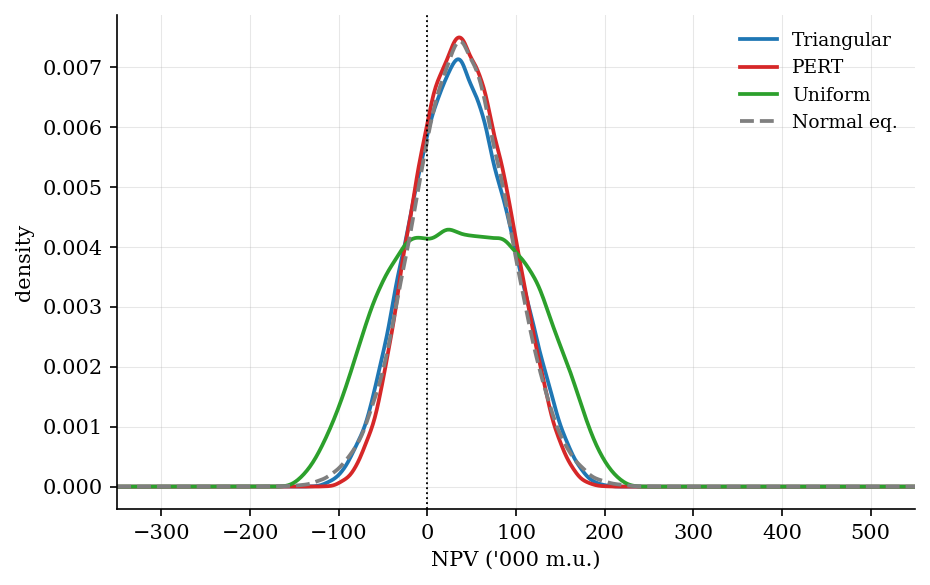

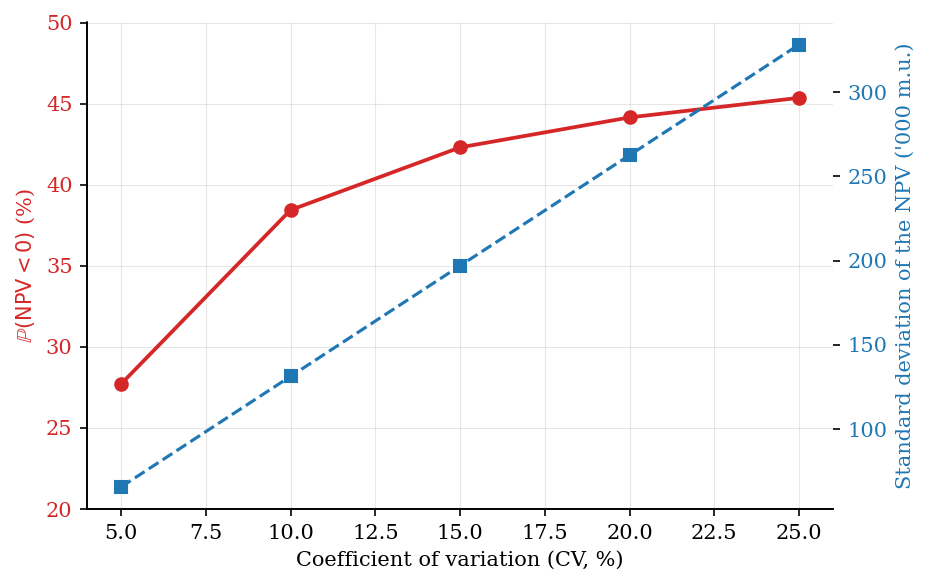

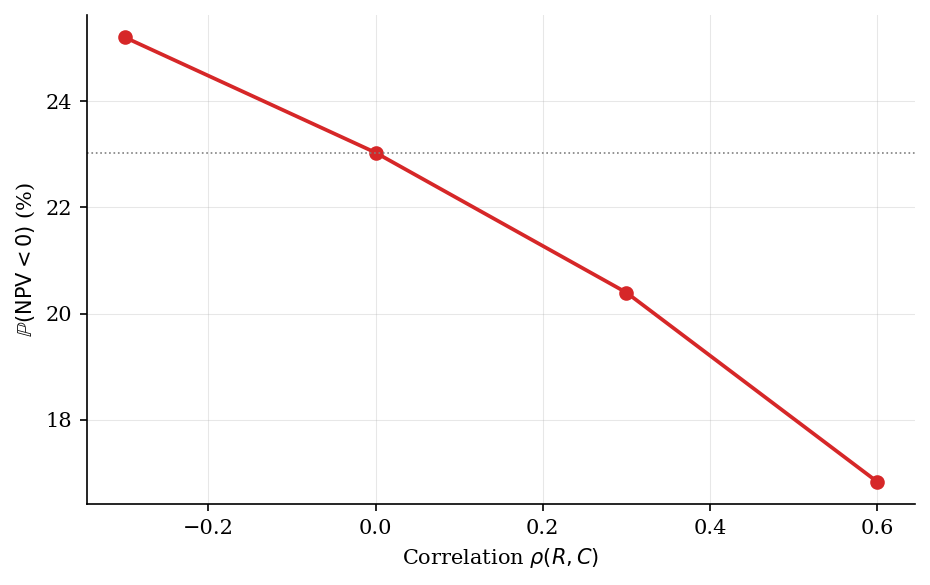

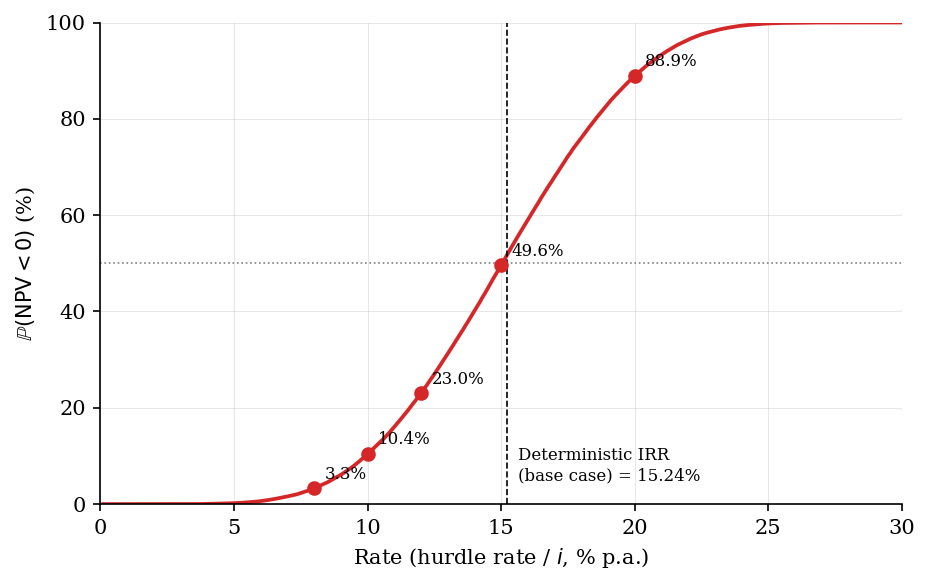

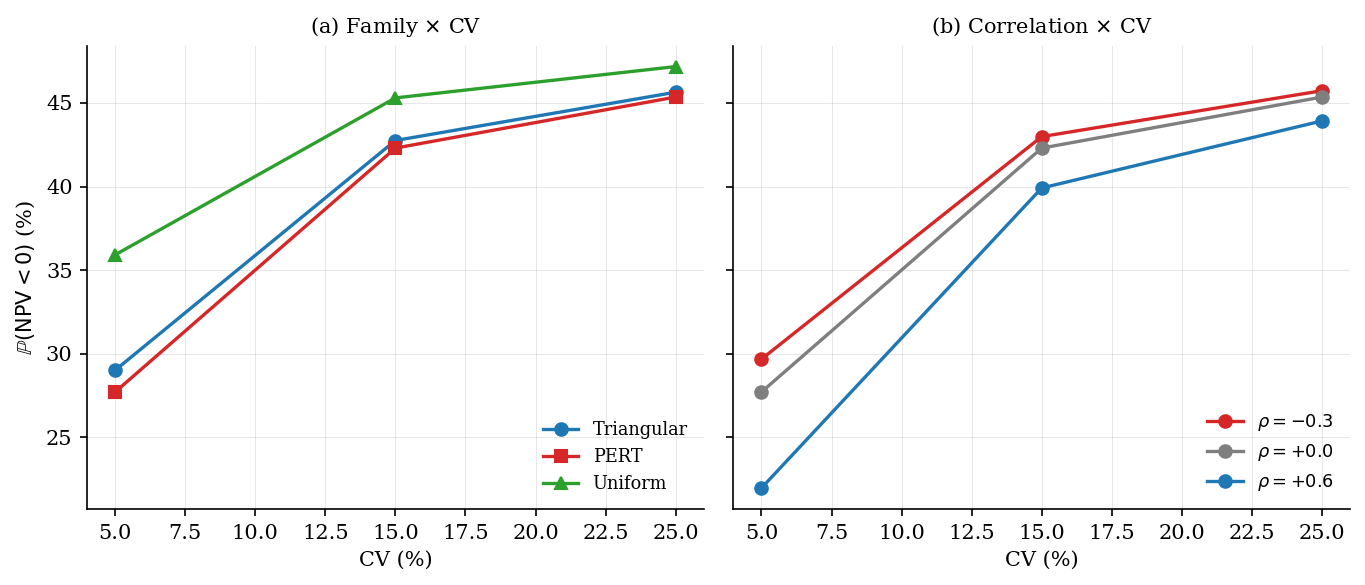

Figures saved to /home/claude/work/nb/figures


In [8]:
"""
fig_results.py -- SELF-CONTAINED CELL for a notebook (Jupyter/Colab).
Paste and run. Depends on no other file or cell. No name clashes between axes.

Generates the five figures of the Results section and saves them to
./figures/*.pdf, also displaying each one inline via plt.show().

File names match the \\includegraphics calls in the manuscript.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ===========================================================================
# 1. CORE (equivalent to mc_experiment.py)
# ===========================================================================
MASTER_SEED = 2026
N_DEFAULT = 100_000

CANON = {
    "I": dict(a=480_000, m=500_000, b=540_000),
    "R": dict(a=270_000, m=300_000, b=336_000),
    "C": dict(a=138_000, m=150_000, b=165_000),
}
N_YEARS = 5
BASE_HURDLE = 0.12


def annuity_factor(hurdle, n=N_YEARS):
    hurdle = np.asarray(hurdle, dtype=float)
    return np.where(np.abs(hurdle) < 1e-12, float(n),
                    (1 - (1 + hurdle) ** (-n)) / hurdle)


def ppf_triangular(u, a, m, b):
    c = (m - a) / (b - a)
    return stats.triang.ppf(u, c=c, loc=a, scale=b - a)


def ppf_pert(u, a, m, b, lam=4.0):
    alpha1 = 1 + lam * (m - a) / (b - a)
    alpha2 = 1 + lam * (b - m) / (b - a)
    return a + (b - a) * stats.beta.ppf(u, alpha1, alpha2)


def ppf_uniform(u, a, m, b):
    return stats.uniform.ppf(u, loc=a, scale=b - a)


def moments_triangular(a, m, b):
    mu = (a + m + b) / 3
    var = (a**2 + m**2 + b**2 - a*m - a*b - m*b) / 18
    return mu, var


def moments_pert(a, m, b, lam=4.0):
    mu = (a + lam * m + b) / (lam + 2)
    var = (mu - a) * (b - mu) / (lam + 3)
    return mu, var


def moments_uniform(a, m, b):
    mu = (a + b) / 2
    var = (b - a) ** 2 / 12
    return mu, var


MOMENTS = {
    "triangular": moments_triangular,
    "pert": moments_pert,
    "uniform": moments_uniform,
}


def ppf_normal_eq(u, a, m, b, ref="triangular"):
    mu, var = MOMENTS[ref](a, m, b)
    return stats.norm.ppf(u, loc=mu, scale=np.sqrt(var))


FAMILIES = {
    "Triangular": (ppf_triangular, "triangular"),
    "PERT": (ppf_pert, "pert"),
    "Uniform": (ppf_uniform, "uniform"),
    "Normal eq.": (ppf_normal_eq, "triangular"),
}


def draw_inputs(rng, elicit, family, N, rho=0.0):
    ppf_func, _ = FAMILIES[family]
    u_I = rng.random(N)
    I = ppf_func(u_I, **elicit["I"])
    z1 = rng.standard_normal(N)
    z2_indep = rng.standard_normal(N)
    z2 = rho * z1 + np.sqrt(1 - rho**2) * z2_indep
    u_R = stats.norm.cdf(z1)
    u_C = stats.norm.cdf(z2)
    R = ppf_func(u_R, **elicit["R"])
    C = ppf_func(u_C, **elicit["C"])
    return I, R, C


def npv(I, R, C, hurdle, n=N_YEARS):
    S = annuity_factor(hurdle, n)
    return -I + (R - C) * S


def summarise(values, N):
    mean = values.mean()
    sd = values.std(ddof=1)
    p_neg = (values < 0).mean()
    se_p = np.sqrt(p_neg * (1 - p_neg) / N)
    p5, p50, p95 = np.percentile(values, [5, 50, 95])
    return dict(mean=mean, sd=sd, p_neg=p_neg, se_p=se_p, p5=p5, p50=p50, p95=p95)


def symmetric_elicitation(cv):
    L_FACTOR = np.sqrt(28)
    elicit = {}
    for var_name, point in CANON.items():
        m = point["m"]
        sigma_target = cv * m
        L = sigma_target * L_FACTOR
        elicit[var_name] = dict(a=m - L / 2, m=m, b=m + L / 2)
    return elicit


# ===========================================================================
# 2. PER-AXIS COMPUTATIONS (unique names -- no clashes)
# ===========================================================================
def run_axis2_cv(N=N_DEFAULT, seed=MASTER_SEED):
    rows = []
    for cv in [0.05, 0.10, 0.15, 0.20, 0.25]:
        elicit = symmetric_elicitation(cv)
        rng = np.random.default_rng(seed)
        I, R, C = draw_inputs(rng, elicit, "PERT", N, rho=0.0)
        rows.append(dict(cv=cv, **summarise(npv(I, R, C, BASE_HURDLE), N)))
    return rows


def run_axis3_correlation(N=N_DEFAULT, seed=MASTER_SEED):
    rows = []
    for rho in [-0.3, 0.0, 0.3, 0.6]:
        rng = np.random.default_rng(seed)
        I, R, C = draw_inputs(rng, CANON, "PERT", N, rho=rho)
        rows.append(dict(rho=rho, **summarise(npv(I, R, C, BASE_HURDLE), N)))
    return rows


def run_axis4_hurdle(N=N_DEFAULT, seed=MASTER_SEED):
    rng = np.random.default_rng(seed)
    I, R, C = draw_inputs(rng, CANON, "PERT", N, rho=0.0)
    reported_hurdles = [0.08, 0.10, 0.12, 0.15, 0.20]
    fine_grid = np.linspace(0.001, 0.40, 400)

    def f_irr(i_grid):
        S = annuity_factor(i_grid)
        npv_grid = -I[:, None] + (R - C)[:, None] * S[None, :]
        return (npv_grid < 0).mean(axis=0)

    return reported_hurdles, f_irr(np.array(reported_hurdles)), fine_grid, f_irr(fine_grid)


def run_family_x_cv(N=N_DEFAULT, seed=MASTER_SEED):
    results = {}
    for family in ["Triangular", "PERT", "Uniform"]:
        row = []
        for cv in [0.05, 0.15, 0.25]:
            elicit = symmetric_elicitation(cv)
            rng = np.random.default_rng(seed)
            I, R, C = draw_inputs(rng, elicit, family, N, rho=0.0)
            row.append(summarise(npv(I, R, C, BASE_HURDLE), N)["p_neg"])
        results[family] = row
    return results


def run_correlation_x_cv(N=N_DEFAULT, seed=MASTER_SEED):
    results = {}
    for rho in [-0.3, 0.0, 0.6]:
        row = []
        for cv in [0.05, 0.15, 0.25]:
            elicit = symmetric_elicitation(cv)
            rng = np.random.default_rng(seed)
            I, R, C = draw_inputs(rng, elicit, "PERT", N, rho=rho)
            row.append(summarise(npv(I, R, C, BASE_HURDLE), N)["p_neg"])
        results[rho] = row
    return results


# ===========================================================================
# 3. FIGURES
# ===========================================================================
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 150,
})
COLOUR = {"Triangular": "#1f77b4", "PERT": "#d62728",
          "Uniform": "#2ca02c", "Normal eq.": "#7f7f7f"}
MARKER = {"Triangular": "o", "PERT": "s", "Uniform": "^", "Normal eq.": "D"}
LINESTYLE = {"Triangular": "-", "PERT": "-", "Uniform": "-", "Normal eq.": "--"}

YLABEL_RISK = r"$\mathbb{P}(\mathrm{NPV}<0)$ (%)"


def fig1_densities():
    fig, ax = plt.subplots(figsize=(6.3, 4.0))
    grid = np.linspace(-350_000, 550_000, 800)
    for name, (_, ref_key) in FAMILIES.items():
        rng = np.random.default_rng(MASTER_SEED)
        I, R, C = draw_inputs(rng, CANON, name, N_DEFAULT, rho=0.0)
        kde = stats.gaussian_kde(npv(I, R, C, BASE_HURDLE))
        ax.plot(grid / 1000, kde(grid) * 1000, label=name,
                color=COLOUR[name], linestyle=LINESTYLE[name], linewidth=1.8)
    ax.axvline(0, color="black", linewidth=0.9, linestyle=":")
    ax.set_xlabel("NPV ('000 m.u.)")
    ax.set_ylabel("density")
    ax.set_xlim(-350, 550)
    ax.legend(frameon=False, loc="upper right", fontsize=9)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/fig1_densities.pdf")
    plt.show()


def fig2_cv():
    rows = run_axis2_cv()
    cvs = [r["cv"] * 100 for r in rows]
    p_neg = [r["p_neg"] * 100 for r in rows]
    sd = [r["sd"] / 1000 for r in rows]
    fig, ax1 = plt.subplots(figsize=(6.3, 4.0))
    ax1.plot(cvs, p_neg, "o-", color="#d62728", linewidth=1.8)
    ax1.set_xlabel("Coefficient of variation (CV, %)")
    ax1.set_ylabel(YLABEL_RISK, color="#d62728")
    ax1.tick_params(axis="y", labelcolor="#d62728")
    ax1.set_ylim(20, 50)
    ax2 = ax1.twinx()
    ax2.plot(cvs, sd, "s--", color="#1f77b4", linewidth=1.5)
    ax2.set_ylabel("Standard deviation of the NPV ('000 m.u.)", color="#1f77b4")
    ax2.tick_params(axis="y", labelcolor="#1f77b4")
    ax2.grid(False)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/fig2_cv.pdf")
    plt.show()


def fig3_correlation():
    rows = run_axis3_correlation()
    rhos = [r["rho"] for r in rows]
    p_neg = [r["p_neg"] * 100 for r in rows]
    fig, ax = plt.subplots(figsize=(6.3, 4.0))
    ax.plot(rhos, p_neg, "o-", color="#d62728", linewidth=1.8)
    ax.axhline(p_neg[rhos.index(0.0)], color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel(r"Correlation $\rho(R,C)$")
    ax.set_ylabel(YLABEL_RISK)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/fig3_correlation.pdf")
    plt.show()


def fig4_risk_curve():
    hurdles, p_rep, grid, curve = run_axis4_hurdle()
    fig, ax = plt.subplots(figsize=(6.3, 4.0))
    ax.plot(grid * 100, curve * 100, "-", color="#d62728", linewidth=1.8)
    ax.plot(np.array(hurdles) * 100, np.array(p_rep) * 100, "o",
            color="#d62728", markersize=6, zorder=5)
    for hurdle, p in zip(hurdles, p_rep):
        ax.annotate(f"{p*100:.1f}%", xy=(hurdle*100, p*100),
                    xytext=(hurdle*100 + 0.4, p*100 + 2), fontsize=8)
    ax.axhline(50, color="gray", linewidth=0.8, linestyle=":")
    ax.axvline(15.24, color="black", linewidth=0.8, linestyle="--")
    ax.text(15.24 + 0.4, 5, "Deterministic IRR\n(base case) = 15.24%", fontsize=8)
    ax.set_xlabel("Rate (hurdle rate / $i$, % p.a.)")
    ax.set_ylabel(YLABEL_RISK)
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 100)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/fig4_risk_curve.pdf")
    plt.show()


def fig5_interactions():
    fam_cv = run_family_x_cv()
    corr_cv = run_correlation_x_cv()
    cvs = [cv * 100 for cv in [0.05, 0.15, 0.25]]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 4.0), sharey=True)
    for family, vals in fam_cv.items():
        ax1.plot(cvs, [v * 100 for v in vals], marker=MARKER[family],
                 color=COLOUR[family], linestyle=LINESTYLE[family],
                 linewidth=1.6, label=family)
    ax1.set_xlabel("CV (%)")
    ax1.set_ylabel(YLABEL_RISK)
    ax1.set_title(r"(a) Family $\times$ CV", fontsize=10)
    ax1.legend(frameon=False, fontsize=8.5, loc="lower right")
    rho_colours = {-0.3: "#d62728", 0.0: "#7f7f7f", 0.6: "#1f77b4"}
    for rho, vals in corr_cv.items():
        ax2.plot(cvs, [v * 100 for v in vals], marker="o",
                 color=rho_colours[rho], linewidth=1.6, label=fr"$\rho={rho:+.1f}$")
    ax2.set_xlabel("CV (%)")
    ax2.set_title(r"(b) Correlation $\times$ CV", fontsize=10)
    ax2.legend(frameon=False, fontsize=8.5, loc="lower right")
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/fig5_interactions.pdf")
    plt.show()


# ===========================================================================
# 4. RUN EVERYTHING
# ===========================================================================
fig1_densities()
fig2_cv()
fig3_correlation()
fig4_risk_curve()
fig5_interactions()
print("Figures saved to", os.path.abspath(OUTDIR))